In [1]:
# ==========================
# Import Required Libraries
# ==========================

# Numerical operations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Generate synthetic dataset
from sklearn.datasets import make_classification

# Split dataset
from sklearn.model_selection import train_test_split

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Save model
import pickle

In [2]:
# ==========================
# Generate Synthetic Dataset
# ==========================

X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    weights=[0.75, 0.25],      # Create class imbalance
    flip_y=0.03,               # Introduce some label noise
    random_state=42
)

# Create feature names
columns = [f"Feature_{i}" for i in range(1, 11)]

# Convert into DataFrame
df = pd.DataFrame(X, columns=columns)

# Add target column
df["Target"] = y

# Display first five rows
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,1.181949,0.351568,0.126179,-0.009413,-1.023795,-0.076360,-0.194985,-1.383993,-0.129196,-0.425376,1
1,1.967278,-6.195386,1.715192,-0.412894,-1.583272,2.554972,0.060050,4.614883,0.501733,4.454262,1
2,2.314324,-1.013817,-0.636351,0.387532,-1.661574,0.322415,-1.231374,-1.508113,-0.054189,0.263591,0
3,-0.606122,-0.106802,-0.128591,0.266211,-0.772109,-1.174956,-1.764976,-2.057340,-0.831149,0.567307,0
4,3.698252,2.194605,-0.586008,1.399442,-0.551834,-3.932449,1.566091,-3.333334,1.139922,0.179579,0


In [55]:
# # Step 2 : Make the Dataset Messy

# Real-world datasets are rarely clean.

# To simulate a practical machine learning project, we will intentionally introduce:

# - Missing values
# - Duplicate records
# - Outliers
# - Unnecessary columns
# - Random categorical values
# - Shuffled rows

# Later, we will clean this dataset before training our model.

In [4]:
# Create a copy
messy_df = df.copy()

# -------------------------------
# Add Missing Values
# -------------------------------

for col in ["Feature_2", "Feature_5", "Feature_8"]:
    
    random_index = messy_df.sample(120, random_state=42).index
    
    messy_df.loc[random_index, col] = np.nan


# -------------------------------
# Duplicate Records
# -------------------------------

duplicates = messy_df.sample(60, random_state=7)

messy_df = pd.concat([messy_df, duplicates], ignore_index=True)


# -------------------------------
# Create Outliers
# -------------------------------

outlier_index = messy_df.sample(35, random_state=20).index

messy_df.loc[outlier_index, "Feature_3"] *= 12


# -------------------------------
# Add Unnecessary Columns
# -------------------------------

messy_df["Customer_ID"] = np.arange(10001, 10001 + len(messy_df))

messy_df["Remarks"] = np.random.choice(
    ["Good", "Average", "Poor"],
    size=len(messy_df)
)


# -------------------------------
# Shuffle Dataset
# -------------------------------

messy_df = messy_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape :", messy_df.shape)

messy_df.head()

Dataset Shape : (5060, 13)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target,Customer_ID,Remarks
0,2.734573,2.660491,0.404585,1.346014,-2.388649,-1.852500,-0.022695,-5.636270,0.671961,-1.873600,0,13106,Average
1,0.143214,-0.144152,-0.117729,-0.445793,-1.501651,0.033971,2.414334,-0.197168,1.561042,0.612224,0,13787,Average
2,-2.295780,3.124419,-1.952513,-0.298173,2.057308,-1.965316,-0.364073,-0.871744,-1.799759,-1.485441,0,14330,Poor
3,2.717086,-0.742327,0.847300,-0.151449,-0.461121,1.310381,-1.652351,-1.457266,1.717684,-1.282769,1,11256,Good
4,2.552748,-3.621837,0.037682,-0.035078,0.373331,2.141322,-2.845015,1.061710,1.972968,0.656708,1,12252,Average


In [56]:
# # Step 3 : Explore the Dataset

# Before building a Machine Learning model, it is important to understand the dataset.

# We will answer the following questions:

# - How many rows and columns are present?
# - What are the data types?
# - Are there any missing values?
# - Are there duplicate records?
# - What is the class distribution?
# - What does the statistical summary look like?

In [6]:
# Display first five rows
messy_df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target,Customer_ID,Remarks
0,2.734573,2.660491,0.404585,1.346014,-2.388649,-1.852500,-0.022695,-5.636270,0.671961,-1.873600,0,13106,Average
1,0.143214,-0.144152,-0.117729,-0.445793,-1.501651,0.033971,2.414334,-0.197168,1.561042,0.612224,0,13787,Average
2,-2.295780,3.124419,-1.952513,-0.298173,2.057308,-1.965316,-0.364073,-0.871744,-1.799759,-1.485441,0,14330,Poor
3,2.717086,-0.742327,0.847300,-0.151449,-0.461121,1.310381,-1.652351,-1.457266,1.717684,-1.282769,1,11256,Good
4,2.552748,-3.621837,0.037682,-0.035078,0.373331,2.141322,-2.845015,1.061710,1.972968,0.656708,1,12252,Average


In [7]:
# Display last five rows
messy_df.tail()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target,Customer_ID,Remarks
5055,0.873625,-1.672527,-0.016260,-0.533017,-1.773945,-2.351595,-2.836315,-3.477804,0.151195,2.234149,0,14427,Poor
5056,-1.848599,0.435223,-1.305547,0.018463,-1.823009,0.908478,-0.579082,-3.174696,1.923425,-1.389926,0,10467,Good
5057,1.358152,-4.237215,-0.983312,-0.898627,-1.796830,1.209212,-3.548611,-0.297051,-0.127850,2.345549,0,13093,Good
5058,2.888250,-3.073852,-1.535826,1.787113,0.222469,1.034907,-2.238694,1.160438,0.660005,1.278195,1,13773,Average
5059,0.436610,2.732948,0.547267,2.585384,0.606099,2.142577,0.736957,0.097856,-0.841025,-3.805362,1,10861,Average


In [8]:
# Shape of the dataset

print("Number of Rows :", messy_df.shape[0])
print("Number of Columns :", messy_df.shape[1])

Number of Rows : 5060
Number of Columns : 13


In [9]:
# Statistical Summary

messy_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature_1,5060.0,0.009305,1.934808,-7.029707,-1.292722,0.059323,1.351538,6.081236
Feature_2,4940.0,1.080470,2.333635,-8.009542,-0.396099,1.190729,2.625464,11.157335
Feature_3,5060.0,0.001670,1.386258,-24.044209,-0.709120,-0.012437,0.695763,20.926031
Feature_4,5060.0,-0.007383,1.002682,-3.532818,-0.686974,-0.005303,0.668159,3.727833
Feature_5,4940.0,-0.987971,1.411101,-5.661886,-1.901459,-0.989976,-0.073200,4.375547
Feature_6,5060.0,-0.540919,1.643106,-6.614786,-1.669156,-0.573702,0.562026,5.358742
Feature_7,5060.0,0.016831,1.819821,-5.403297,-1.210819,0.015847,1.243029,6.585695
Feature_8,4940.0,-2.185527,2.808796,-13.169284,-4.031039,-2.378089,-0.516288,10.069869
Feature_9,5060.0,0.250841,1.582036,-6.097171,-0.876689,0.254076,1.334070,6.227987
Feature_10,5060.0,-0.761612,1.631682,-6.073768,-1.865106,-0.783165,0.298635,5.535452


In [10]:
# Check Data Types

messy_df.dtypes

Feature_1      float64
Feature_2      float64
Feature_3      float64
Feature_4      float64
Feature_5      float64
Feature_6      float64
Feature_7      float64
Feature_8      float64
Feature_9      float64
Feature_10     float64
Target           int32
Customer_ID      int32
Remarks         object
dtype: object

In [57]:
# # Step 4 : Missing Value Analysis

# Missing values are common in real-world datasets.

# If not handled properly, they can negatively impact the model's performance.

# Let's identify which columns contain missing values.

In [12]:
# Missing Value Percentage

missing = (messy_df.isnull().sum()/len(messy_df))*100

missing.sort_values(ascending=False)

Feature_2      2.371542
Feature_5      2.371542
Feature_8      2.371542
Feature_1      0.000000
Feature_3      0.000000
Feature_4      0.000000
Feature_6      0.000000
Feature_7      0.000000
Feature_9      0.000000
Feature_10     0.000000
Target         0.000000
Customer_ID    0.000000
Remarks        0.000000
dtype: float64

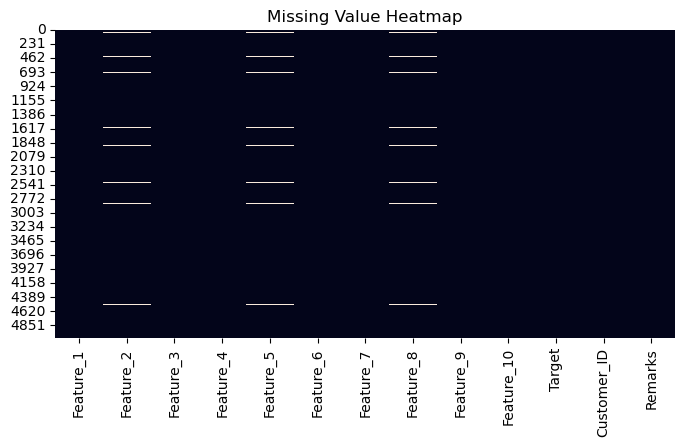

In [13]:
# Visualize Missing Values

plt.figure(figsize=(8,4))

sns.heatmap(messy_df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

In [58]:
# # Step 5 : Duplicate Record Analysis

# Duplicate records can bias a Machine Learning model.

# Let's identify and remove duplicate rows.

In [15]:
# Number of duplicate records

messy_df.duplicated().sum()

0

In [59]:
# # Step 6 : Target Variable Distribution

# Before training a classification model, we should understand the distribution of the target variable.

# A highly imbalanced dataset can make Accuracy misleading.

In [17]:
# Count target values

messy_df["Target"].value_counts()

Target
0    3757
1    1303
Name: count, dtype: int64

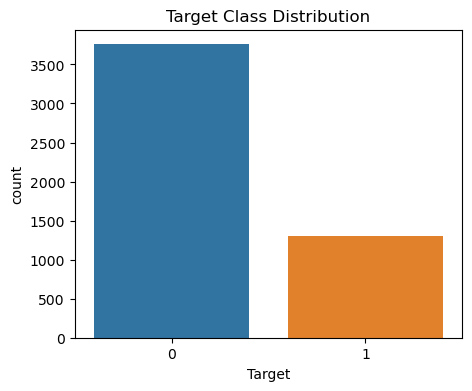

In [18]:
plt.figure(figsize=(5,4))

sns.countplot(x="Target", data=messy_df)

plt.title("Target Class Distribution")

plt.show()

In [60]:
# # Step 7 : Data Cleaning

# Now we will clean the dataset by

# - Removing duplicate rows
# - Filling missing values
# - Removing unnecessary columns
# - Handling outliers

# The cleaned dataset will then be used for Machine Learning.

In [20]:
# Remove duplicate rows

messy_df = messy_df.drop_duplicates()

print("Shape after removing duplicates :", messy_df.shape)

Shape after removing duplicates : (5060, 13)


In [21]:
# Fill missing values using Median

for col in ["Feature_2","Feature_5","Feature_8"]:
    
    messy_df[col].fillna(messy_df[col].median(), inplace=True)

In [22]:
# Verify missing values

messy_df.isnull().sum()

Feature_1      0
Feature_2      0
Feature_3      0
Feature_4      0
Feature_5      0
Feature_6      0
Feature_7      0
Feature_8      0
Feature_9      0
Feature_10     0
Target         0
Customer_ID    0
Remarks        0
dtype: int64

In [23]:
# Remove unnecessary columns

messy_df.drop(["Customer_ID","Remarks"], axis=1, inplace=True)

messy_df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,2.734573,2.660491,0.404585,1.346014,-2.388649,-1.852500,-0.022695,-5.636270,0.671961,-1.873600,0
1,0.143214,-0.144152,-0.117729,-0.445793,-1.501651,0.033971,2.414334,-0.197168,1.561042,0.612224,0
2,-2.295780,3.124419,-1.952513,-0.298173,2.057308,-1.965316,-0.364073,-0.871744,-1.799759,-1.485441,0
3,2.717086,-0.742327,0.847300,-0.151449,-0.461121,1.310381,-1.652351,-1.457266,1.717684,-1.282769,1
4,2.552748,-3.621837,0.037682,-0.035078,0.373331,2.141322,-2.845015,1.061710,1.972968,0.656708,1


In [61]:
# # Step 8 : Outlier Detection

# Outliers are observations that lie far away from the majority of the data.

# We will use the IQR (Interquartile Range) method to detect and remove them.

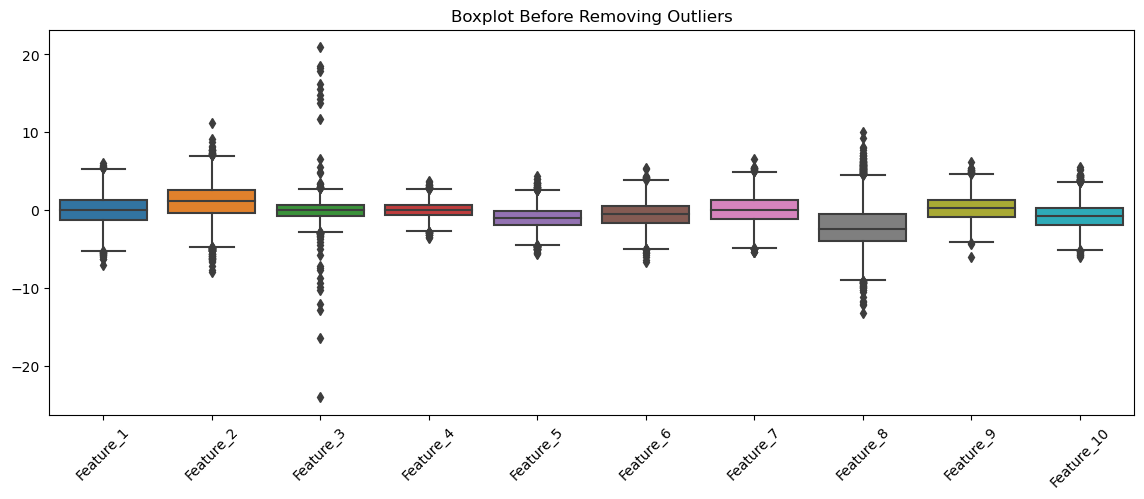

In [25]:
plt.figure(figsize=(14,5))

sns.boxplot(data=messy_df.drop("Target",axis=1))

plt.xticks(rotation=45)

plt.title("Boxplot Before Removing Outliers")

plt.show()

In [26]:
# Remove Outliers using IQR

Q1 = messy_df.quantile(0.25)

Q3 = messy_df.quantile(0.75)

IQR = Q3 - Q1

clean_df = messy_df[
    ~((messy_df < (Q1 - 1.5 * IQR)) |
      (messy_df > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Original Shape :", messy_df.shape)

print("Cleaned Shape :", clean_df.shape)

Original Shape : (5060, 11)
Cleaned Shape : (4680, 11)


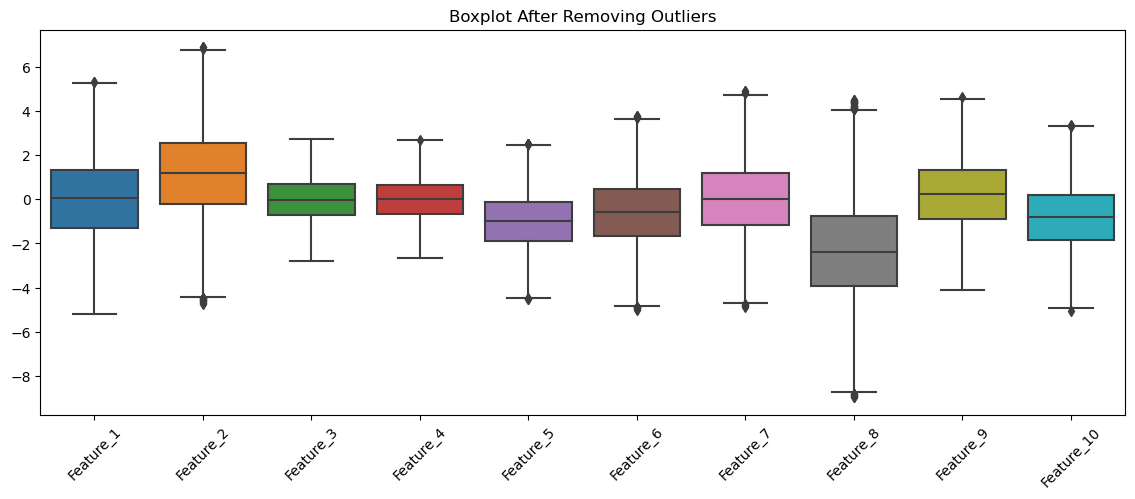

In [27]:
plt.figure(figsize=(14,5))

sns.boxplot(data=clean_df.drop("Target",axis=1))

plt.xticks(rotation=45)

plt.title("Boxplot After Removing Outliers")

plt.show()

In [62]:
# # Step 9 : Feature Selection

# Now that our dataset is clean, we will separate the independent variables (features) and the dependent variable (target).

# - X → Features
# - y → Target Variable

In [29]:
# Separate Features and Target

X = clean_df.drop("Target", axis=1)

y = clean_df["Target"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (4680, 10)
Target Shape : (4680,)


In [63]:
# # Step 10 : Train-Test Split

# Machine Learning models should be evaluated on unseen data.

# We split the dataset into:

# - Training Data (80%)
# - Testing Data (20%)

# The model learns from the training data and is evaluated using the testing data.

In [31]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (3744, 10)
Testing Data : (936, 10)


In [64]:
# # Step 11 : Train Logistic Regression Model

# Logistic Regression is one of the most popular algorithms for Binary Classification.

# The model learns patterns from the training dataset.

In [65]:
# Create the model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train, y_train)

print("Model Trained Successfully")

In [66]:
# # Step 12 : Make Predictions

# After training the model, we use it to predict the target values for the testing dataset.

In [35]:
# Predict on testing data

y_pred = model.predict(X_test)

print("First 20 Predictions")

print(y_pred[:20])

First 20 Predictions
[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [36]:
# Compare Actual vs Predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,1
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


In [37]:
# ==========================
# Save the Trained Model
# ==========================

# Save the trained Logistic Regression model
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as logistic_model.pkl")

Model saved successfully as logistic_model.pkl


In [67]:
# # Load the Saved Model

# The trained model can be stored permanently using Pickle.

# Instead of training the model every time, we can load the saved model and use it directly for prediction.

In [39]:
# ==========================
# Load the Saved Model
# ==========================

with open("logistic_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully.")

Model loaded successfully.


In [40]:
# Make predictions using the loaded model

loaded_predictions = loaded_model.predict(X_test)

print("First 10 Predictions")

loaded_predictions[:10]

First 10 Predictions


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [41]:
# Compare original and loaded model predictions

print("Original Model Predictions")
print(y_pred[:10])

print("\nLoaded Model Predictions")
print(loaded_predictions[:10])

Original Model Predictions
[0 0 0 0 1 0 0 0 0 0]

Loaded Model Predictions
[0 0 0 0 1 0 0 0 0 0]


In [42]:
# Verify whether both predictions are identical

np.array_equal(y_pred, loaded_predictions)

True

In [43]:
# ==========================
# Accuracy Score
# ==========================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.4f}")
print(f"Accuracy Percentage : {accuracy*100:.2f}%")

Accuracy Score : 0.8077
Accuracy Percentage : 80.77%


In [44]:
# ==========================
# Precision Score
# ==========================

from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision Score : {precision:.4f}")
print(f"Precision Percentage : {precision*100:.2f}%")

Precision Score : 0.6268
Precision Percentage : 62.68%


In [45]:
# ==========================
# Recall Score
# ==========================

from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall Score : {recall:.4f}")
print(f"Recall Percentage : {recall*100:.2f}%")

Recall Score : 0.4120
Recall Percentage : 41.20%


In [46]:
# ==========================
# F1 Score
# ==========================

from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")
print(f"F1 Percentage : {f1*100:.2f}%")

F1 Score : 0.4972
F1 Percentage : 49.72%


In [47]:
# ==========================
# Compare All Metrics
# ==========================

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics

,Metric,Score
0,Accuracy,0.807692
1,Precision,0.626761
2,Recall,0.412037
3,F1-Score,0.497207


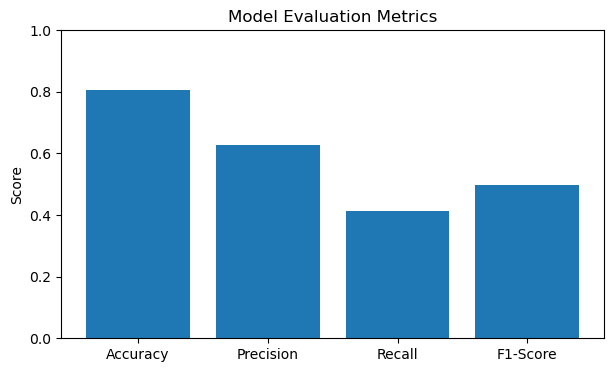

In [48]:
# ==========================
# Visualize Metrics
# ==========================

plt.figure(figsize=(7,4))

plt.bar(metrics["Metric"], metrics["Score"])

plt.ylim(0,1)

plt.title("Model Evaluation Metrics")

plt.ylabel("Score")

plt.show()

In [49]:
# ==========================
# Another Model Comparison
# ==========================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [50]:
# Calculate Metrics for Decision Tree

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

In [51]:
comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1-Score"],
    "Logistic Regression":[accuracy,precision,recall,f1],
    "Decision Tree":[dt_accuracy,dt_precision,dt_recall,dt_f1]
})

comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.807692,0.865385
1,Precision,0.626761,0.699115
2,Recall,0.412037,0.731481
3,F1-Score,0.497207,0.714932


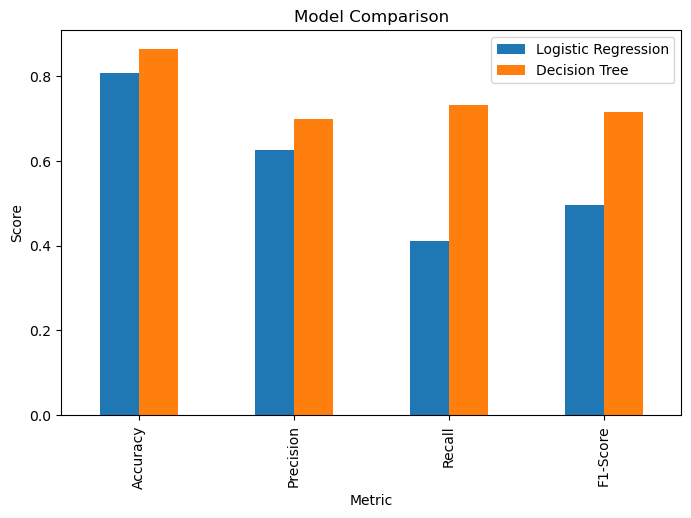

In [52]:
comparison.plot(
    x="Metric",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.show()